---
title: Tuango -- Targeting Mobile App Messages
jupyter: python3
---


In [ ]:
import polars as pl
import pyrsm as rsm
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_hline,
    geom_col,
    geom_text,
    geom_histogram,
    labs,
    theme_minimal
)


In [ ]:
tuango = pl.read_parquet("data/tuango_pre.parquet")
tuango

userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test
str,cat,f64,i32,f64,f64,i32,cat,cat,f64,i32
"""U15889344""","""no""",0.0,309,7.0,39.799999,44,"""F""","""yes""",0.0,1
"""U60246497""","""no""",0.0,297,8.0,39.799999,80,"""M""","""yes""",1.0,1
"""U22965759""","""no""",0.0,295,1.0,72.900002,59,"""F""","""yes""",1.0,1
"""U40811142""","""no""",0.0,277,1.0,40.0,37,"""F""","""yes""",0.0,1
"""U76283952""","""no""",0.0,259,1.0,21.0,43,"""F""","""yes""",1.0,1
…,…,…,…,…,…,…,…,…,…,…
"""U83013842""",null,null,19,4.0,128.0,25,"""F""","""yes""",null,0
"""U45426448""",null,null,131,2.0,110.74,20,"""O""","""yes""",null,0
"""U48935927""",null,null,53,1.0,126.0,71,"""M""","""no""",null,0


In [4]:
# dataset description
tuango_description = rsm.md("data/tuango_pre_description.md")

# Tuango: Targeting Mobile App Push Messages

This file contains information about the test and does not have results about the roll-out. Values for `buyer` and `ordersize` are missing for all customers that were not part of the test.

## Variable Names and Descriptions
* userid: Unique user ID

**Response to the customized push message**
* buyer: Did the customer buy the Karaoke deal? ("yes" or "no")
* ordersize: Number of 30-minute Karaoke sessions the customer purchased

**Recency, Frequency, and Monetary variables**
* recency: Days since last purchase of a deal (before the Karaoke deal offer)
* frequency: Number of deals purchased during the one year period before the Karaoke deal offer
* monetary: Average amount spent per order (in RMB) during the one year period before the Karaoke deal offer

**Other variables in the dataset**
* age: Age of the customer
* gender: Gender identity of the customer (M = male, F = female, O = Other or unknown)
* music: Customer made a purchase in the music category during the one-year period before the Karaoke deal offer ("no" or "yes")
* test: Splits the dataset into test (1) and rollout (0) data
* training: Splits the dataset into training (1) and test (0) data. This variable will not be used in this assignment

In [ ]:
tuango.select(pl.col("buyer").value_counts())

buyer
struct[2]
"{""no"",18888}"
"{""yes"",2020}"
"{null,397252}"


In [ ]:
tuango.select(pl.col("buyer").is_null().value_counts())

buyer
struct[2]
"{false,20908}"
"{true,397252}"


In [ ]:
tuango = tuango.with_columns(
    pl.col("buyer")
    .replace({"yes":1, "no":0})
    .alias("buyer_yes")
)

tuango.select(pl.col("buyer_yes").value_counts())

buyer_yes
struct[2]
"{null,397252}"
"{""no"",18888}"
"{""yes"",2020}"


## Part I:  Preliminary Analysis

What proportion of customers responded to the deal offer message (i.e., bought the deal)?

In [ ]:
# q1 = tuango["buyer_yes"].astype(float).mean()
q1 = (tuango.select(
    pl.when(pl.col("buyer") == "yes").then(1.0)
      .when(pl.col("buyer") == "no").then(0.0)
      .otherwise(None)
      .cast(pl.Int64)
      .mean()
).item())
q1

0.09661373636885402

What was the average number of karaoke sessions purchased by customers that bought one or more 30-minute sessions?

In [ ]:
q2 = (
    tuango
    .group_by("buyer")
    .agg([
        pl.col("ordersize").count().alias("count"),
        pl.col("ordersize").mean().alias("mean"),
        pl.col("ordersize").std().alias("std"),
    ])
    .sort("buyer")
)


q2_yes_mean = (
    q2.filter(pl.col("buyer") == "yes")
    .select("mean")
    .item()
)
q2_yes_mean

3.9410891089108913

## Part II: Building Targeting Models

3.	Estimate a logistic regression model using "buyer" as the response variable (aka target or dependent variable) and, recency, frequency, monetary, age, gender, and music as the explanatory variables (aka features or independent variables).

In [ ]:
tuango_test = tuango.filter(pl.col("buyer").is_not_null())

clf = rsm.model.logistic(
    data = tuango_test,
    rvar = "buyer",
    lev = "yes",
    evar = ["recency", "frequency", "monetary", "age", "gender", "music"],
)
clf.summary()

Logistic regression (GLM)
Data                 : Not provided
Response variable    : buyer
Level                : yes
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

┌───────────┬───────┬────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index     ┆ OR    ┆ OR%    ┆ coefficient ┆ std.error ┆ z.value ┆ p.value ┆     │
╞═══════════╪═══════╪════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept ┆ 0.168 ┆ -83.2% ┆ -1.783      ┆ 0.077     ┆ -23.196 ┆ < .001  ┆ *** │
│ gender[M] ┆ 0.578 ┆ -42.2% ┆ -0.549      ┆ 0.054     ┆ -10.073 ┆ < .001  ┆ *** │
│ gender[O] ┆ 0.623 ┆ -37.7% ┆ -0.474      ┆ 0.123     ┆ -3.863  ┆ < .001  ┆ *** │
│ music[no] ┆ 0.524 ┆ -47.6% ┆ -0.646      ┆ 0.059     ┆ -10.912 ┆ < .001  ┆ *** │
│ recency   ┆ 0.999 ┆ -0.1%  ┆ -0.001      ┆ 0.0       ┆ -3.292  ┆ < .001  ┆ *** │
│ frequency ┆ 1.114 ┆ 11.4%  ┆ 0.108       ┆ 0.01      ┆ 

Create Prediction plots for all explanatory variables using pyrsm. Describe the effect of a change in each explanatory variable on the probability that a customer will purchase the karaoke deal

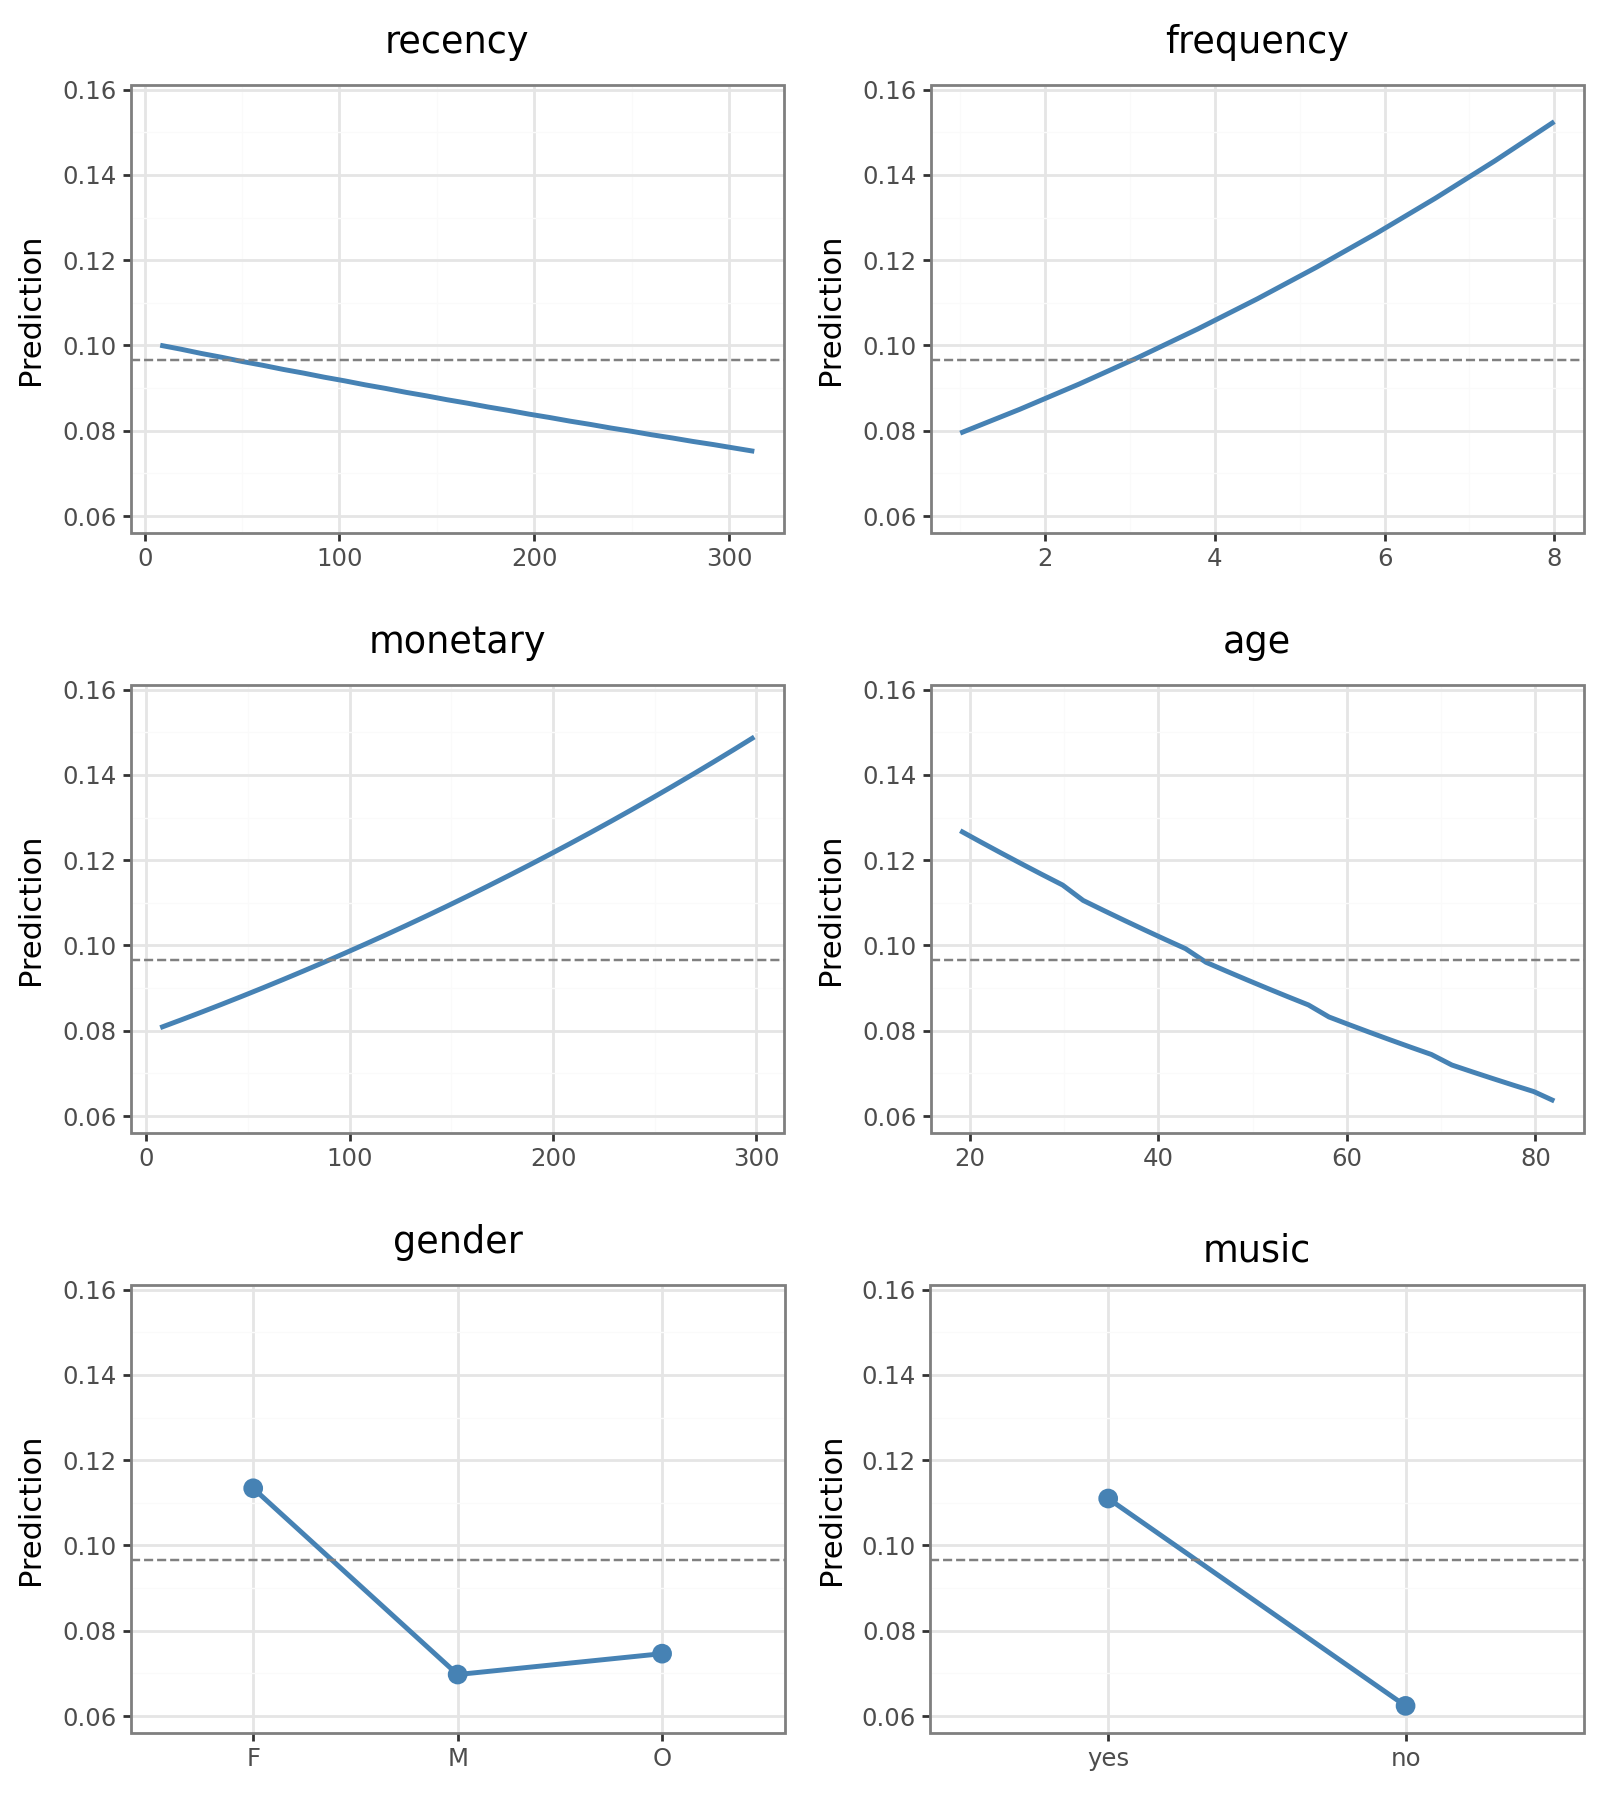

In [11]:
clf.plot("pdp")

### Explanation

**Recency：** As recency increases, the predicted probability of purchasing the karaoke deal decreases, indicating that more recently active customers are more likely to respond to the promotion.
**Frequency:** Customers with higher purchase frequency exhibit a higher predicted probability of purchasing the karaoke deal.
**Monetary:** Higher average spending is associated with a higher predicted probability of purchasing the deal.
**Age:** The predicted probability of purchasing the karaoke deal decreases with age, suggesting that younger customers are more responsive to the offer.
**Gender:** Predicted purchase probabilities vary by gender, with female customers showing the highest likelihood of purchasing the deal, followed by other/unknown, and male customers showing the lowest likelihood.
**Music:** Customers who previously purchased music-related deals have a higher predicted probability of purchasing the karaoke deal than those who did not. 

Use pyrsm to plot Permutation Importance to assess variable importance. Which variables seem to be most and least important in the model?

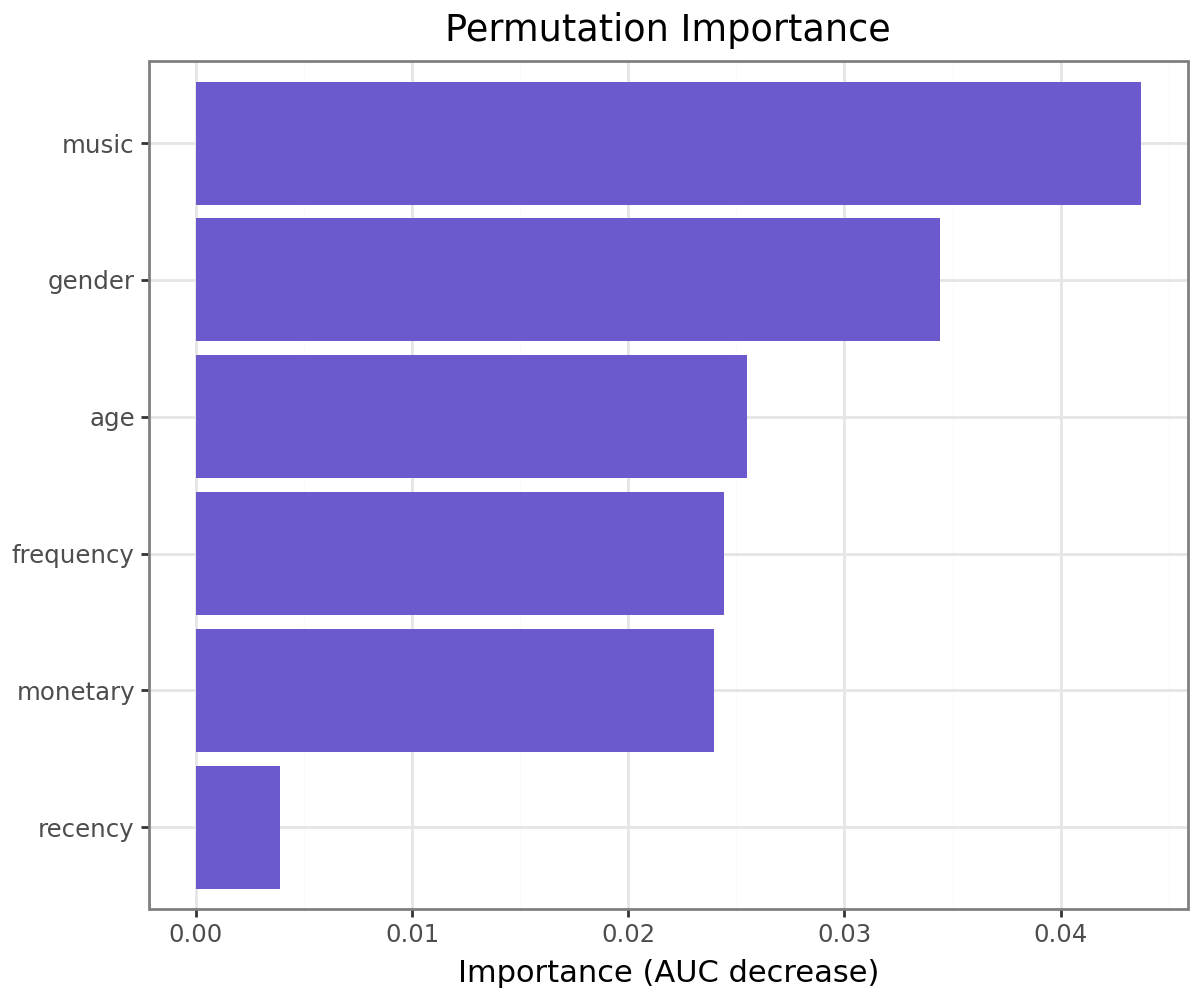

In [12]:
clf.plot("pip")

### Explanation

The results show that music is the most important variable in the model, followed by gender, while recency is the least important variable. Permutation Importance evaluates variable importance by randomly permuting the values of a single variable and measuring the resulting decrease in model performance, which is AUC. A larger decrease in AUC indicates that the model relies more heavily on that variable for prediction, whereas a small or negligible decrease suggests that the variable contributes little additional predictive information. 

Add the predicted values from the logistic regression to the "tuango" DataFrame. Use "pred_logit" as the variable name. Compare the average of the predicted values to the overall response rate (i.e., proportion of buyers). Explain what you notice.

In [13]:
pred = clf.predict(tuango_test)
pred.columns

['recency', 'frequency', 'monetary', 'age', 'gender', 'music', 'prediction']

In [14]:
tuango_test = tuango_test.with_columns(
    pred.select(pl.col("prediction").alias("pred_logit"))
)

tuango_test.select("pred_logit").head()

pred_logit
f64
0.141318
0.064122
0.07271
0.088488
0.080623


In [15]:
actual_rate = (
    tuango_test
    .select(pl.when(pl.col("buyer") == "yes").then(1.0).otherwise(0.0).mean())
    .item()
)

predicted_rate = (
    tuango_test
    .select(pl.col("pred_logit").mean())
    .item()
)

actual_rate, predicted_rate

(0.09661373636885402, 0.09661373636885376)

### Explanation

The average predicted value is almost identical to the overall response rate when the calculation is performed using only the data used to estimate the model. 
This occurs might because logistic regression with an intercept is calibrated such that the mean fitted probability equals the observed proportion of positive outcomes in the estimation sample. So when evaluated on the training data, the model’s average predicted probability matches the overall proportion of buyers. 

Estimate a linear regression model using "ordersize" as the response variable and recency, frequency, monetary, age, gender, and music as the explanatory variables. Estimate this regression using only those customers who placed an order after the deal offer message. Describe why you think it does, or does not, make sense to focus on this group of customers.

In [16]:
tuango_ordered = tuango.filter(pl.col("buyer") == "yes")

lin_model = rsm.model.regress(
    data = tuango_ordered,
    rvar = "ordersize",
    evar = ["recency", "frequency", "monetary", "age", "gender", "music"],
)

lin_model.summary()

Linear regression (OLS)
Data                 : Not provided
Response variable    : ordersize
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: the effect of x on ordersize is zero
Alt. hyp.: the effect of x on ordersize is not zero

┌───────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index     ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞═══════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept ┆ 3.816       ┆ 0.146     ┆ 26.191  ┆ < .001  ┆ *** │
│ gender[O] ┆ 0.132       ┆ 0.199     ┆ 0.664   ┆ 0.507   ┆     │
│ gender[M] ┆ -0.126      ┆ 0.089     ┆ -1.425  ┆ 0.154   ┆     │
│ music[no] ┆ -0.025      ┆ 0.097     ┆ -0.255  ┆ 0.799   ┆     │
│ recency   ┆ 0.0         ┆ 0.001     ┆ 0.591   ┆ 0.555   ┆     │
│ frequency ┆ 0.023       ┆ 0.016     ┆ 1.456   ┆ 0.145   ┆     │
│ monetary  ┆ 0.0         ┆ 0.0       ┆ 1.035   ┆ 0.301   ┆     │
│ age       ┆ 0.001       ┆ 0.003     ┆ 0.389   ┆ 0.697   ┆     │
└───────

### Explanation
It does make sense to focus on customers who placed an order, because order size is only meaningful once a purchase has occurred. **However**, the regression results show that conditional on purchasing, the explanatory variables explain very little variation in order size, as reflected by the very low R-squared. This suggests that while these variables are useful for predicting whether a customer will purchase, they provide limited information about how much the customer purchases once the purchase decision has been made.

Plot Permutation Importance to assess variable importance in the estimation data. Which variables seem to be most important in the model?

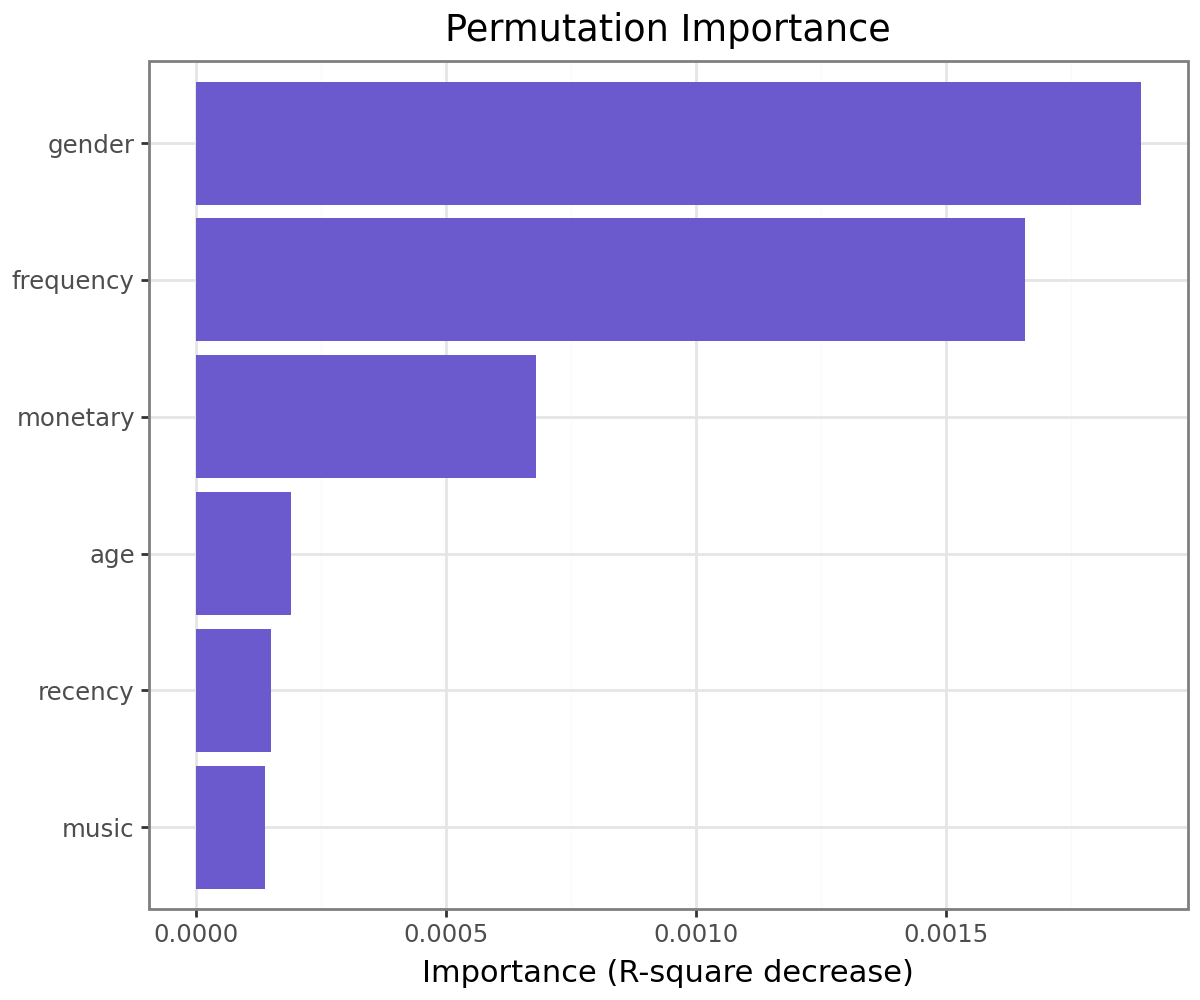

In [17]:
lin_model.plot("pip")

### Explanation
Base on the result, gender and frequency appear to be the most important variables in explaining order size, as permuting these variables leads to the largest decrease in R-squared. Monetary has moderate importance, while age, recency, and music contribute very little to the model’s explanatory power. But, overall, the importance values are small, indicating that even the most important variables explain only a limited portion of the variation in order size. 

What do the linear regression model results suggest about our ability to predict ordersize for customers who responded to the deal?

The linear regression results showed that the ability to predict order size for customers who responded to the deal is very limited. The model has very low explanatory power, as indicated by the low R-squared, and permutation importance shows that no variable strongly influences order size. This implies that while it is reasonable to predict whether a customer will respond to the deal, there is little ability to predict how much they will purchase once they decide to respond.

Add the predicted values from the linear regression to the "tuango" data.frame. What do you notice?

In [18]:
pred_lin = lin_model.predict(tuango_ordered)

tuango_ordered = tuango_ordered.with_columns(
    pred_lin.select(pl.col("prediction").alias("pred_ordersize"))
)

tuango_ordered.select("ordersize", "pred_ordersize").head()

ordersize,pred_ordersize
f64,f64
4.0,3.974319
5.0,4.153051
5.0,4.046473
3.0,4.015176
4.0,3.888904


In [19]:
actual_mean_ordersize = (
    tuango_ordered
    .select(pl.col("ordersize").mean())
    .item()
)

predicted_mean_ordersize = (
    tuango_ordered
    .select(pl.col("pred_ordersize").mean())
    .item()
)

actual_mean_ordersize, predicted_mean_ordersize

(3.9410891089108913, 3.941089108910891)

### Explanation
When focusing only on customers who placed an order, the average predicted order size from the linear regression closely matches the observed average order size. This reflects the fact that the model is estimated on the same sample of buyers and is centered around the overall mean of order size. As a result, the fitted values reproduce the average level of spending in the estimation data, even though the model has limited ability to capture individual-level variation in order size.

## Part III: Profitability Analysis

To calculate profit and return on marketing expenditures assume the following:
- Price per 30-minute session is 49 RMB
- Marginal cost of sending a deal offer message is 9 RMB
- Tuango’s fee on each deal sold is 50% of sales revenues


What is the breakeven response rate?

In [ ]:
cost = 9.0 # float
price = 49.0
fee = 0.5
margin = fee * price * q2_yes_mean # float
breakeven =  cost / margin# float, do not apply rounding, do not express as a percentage
q11 = breakeven # float, DO NOT APPLY ROUNDING, do not express as a percentage
q11

0.09320949834524941

What is the projected profit in RMB and the return on marketing expenditures if you offer the deal to all 397,252 remaining customers (i.e., target everyone)?

In [ ]:
tuango = tuango.with_columns(pl.lit(True).alias("message_all"))

nr_message_all = 397252 # total number of messages that would be sent out
message_cost_all = nr_message_all * 9.0# total cost of sending messages to selected customers (float)

response_rate_all = q1# expressed as a proportion (no rounding)
nr_responses_all = nr_message_all * response_rate_all # total number of positive responses
revenue_all = nr_responses_all * 49.0 * q2_yes_mean # total revenue in RMB (no rounding)

profit_all = 0.5 * revenue_all - message_cost_all
# 0.5 * revenue - message_cost_all = total profit in RMB (no rounding)
rome_all = profit_all / message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)

rome_all, profit_all

(0.036522436919414154, 130577.5)

Evaluate the performance implications of offering the deal to only those customers (out of 397,252) with a predicted probability of purchase greater than the breakeven response rate. Determine the projected profit in RMB and the return on marketing expenditures.

In [47]:
pred = clf.predict(tuango).select(pl.col("prediction").alias("pred_logit"))
tuango = tuango.with_columns(pred)

cost = 9.0
avg_ordersize = (
    tuango
    .filter((pl.col("buyer") == "yes") & (pl.col("test") == 1))
    .select(pl.col("ordersize").mean())
    .item()
)

margin = 0.5 * 49 * avg_ordersize
breakeven = cost / margin

tuango = tuango.with_columns(
    message_logit = (pl.col("pred_logit") > breakeven)
)

response = (
    tuango
    .filter(pl.col("test") == 1)
    .with_columns(buyer_yes = (pl.col("buyer") == "yes").cast(pl.Int64))
    .group_by("message_logit")
    .agg(
        n_obs = pl.len(),
        nr_buyer = pl.col("buyer_yes").sum(),
        perc_buy = pl.col("buyer_yes").mean(),
    )
)

total_obs = response.select(pl.col("n_obs").sum()).item()
response = response.with_columns(
    perc_target = pl.col("n_obs") / total_obs
)

row_true = response.filter(pl.col("message_logit") == True)
perc_target = row_true.select(pl.col("perc_target")).item()
response_rate_logit = row_true.select(pl.col("perc_buy")).item() # expressed as a proportion (no rounding)

rollout_n = 397252
nr_message_logit = int(round(rollout_n * perc_target)) # total number of messages that would be sent out
message_cost_logit = nr_message_logit * cost # total cost of sending messages to selected customers (float)

nr_responses_logit = response_rate_logit * nr_message_logit

avg_ordersize_logit = (
    tuango
    .filter((pl.col("test") == 1) & (pl.col("message_logit") == True) & (pl.col("buyer") == "yes"))
    .select(pl.col("ordersize").mean())
    .item()
)


revenue_logit = nr_responses_logit * 49 * avg_ordersize_logit # total revenue in RMB (no rounding)
profit_logit = 0.5 * revenue_logit - message_cost_logit # 0.5 * revenue_logit - message_cost_logit = total profit in RMB (no rounding)

rome_logit = profit_logit / message_cost_logit # Return on Marketing Expenditures expressed as a proportion (no rounding)

profit_logit, rome_logit, message_cost_logit, nr_message_logit, avg_ordersize_logit, total_obs, nr_responses_logit, perc_target, response_rate_logit

(883975.0,
 0.5623239904758451,
 1572003.0,
 174667,
 3.9699021820917983,
 20908,
 25251.0,
 0.43968815764300745,
 0.14456651800282824)

Use plotnine to create a bar chart with profit information.

In [34]:
profit_df = pl.DataFrame({
    "strategy": ["Target all", "Target by logit"],
    "profit": [profit_all, profit_logit]
})

profit_df

strategy,profit
str,f64
"""Target all""",130577.5
"""Target by logit""",883975.0


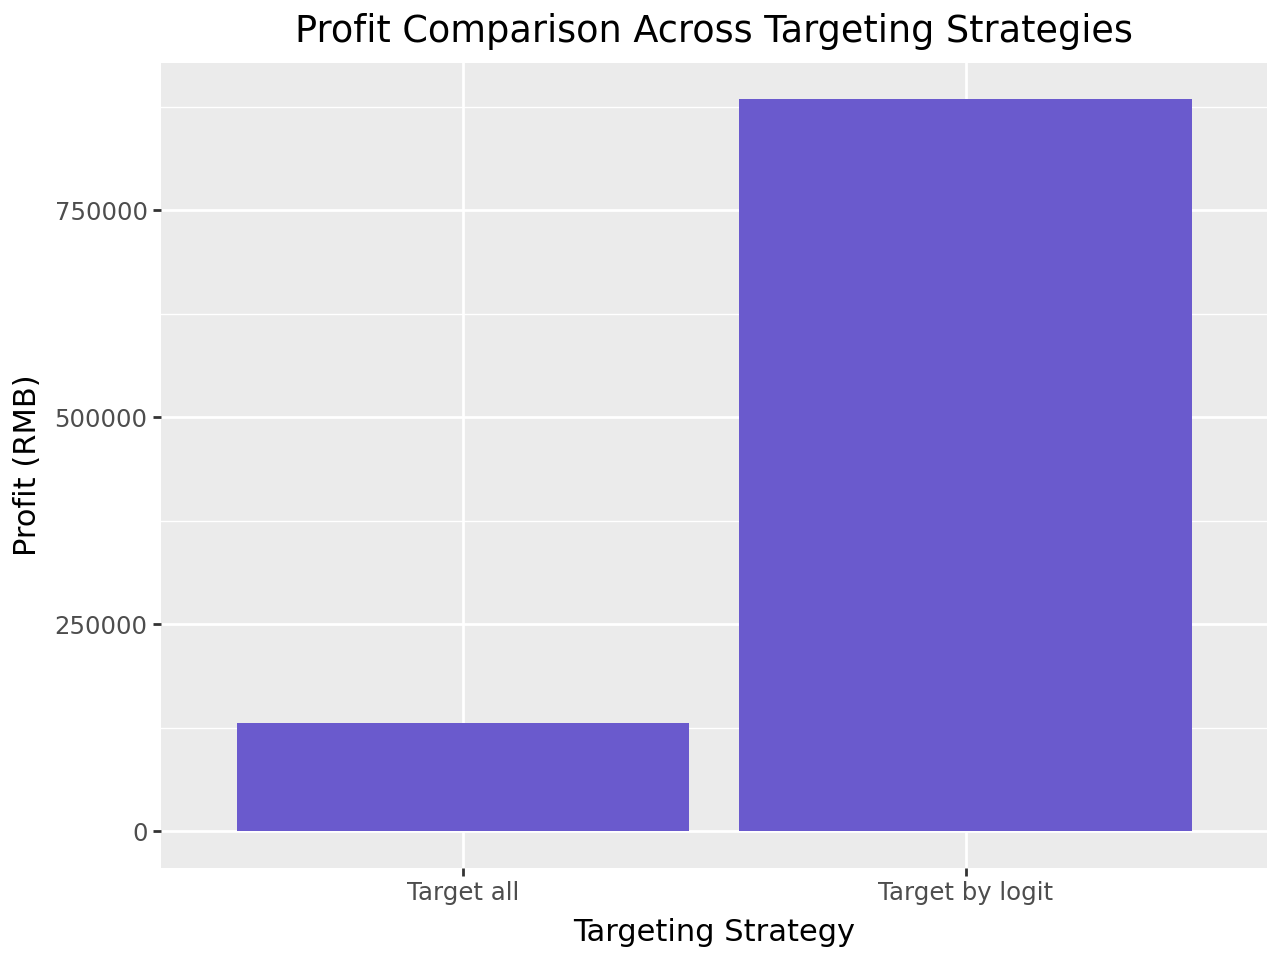

In [35]:
(
    ggplot(profit_df, aes(x="strategy", y="profit"))
    + geom_col(fill = "slateblue")
    + labs(
        title = "Profit Comparison Across Targeting Strategies",
        x="Targeting Strategy",
        y="Profit (RMB)"
    )
)


Use plotnine to create a bar chart with ROME information.

In [36]:
rome_df = pl.DataFrame({
    "strategy": ["Target all", "Target by logit"],
    "rome": [rome_all, rome_logit]
})


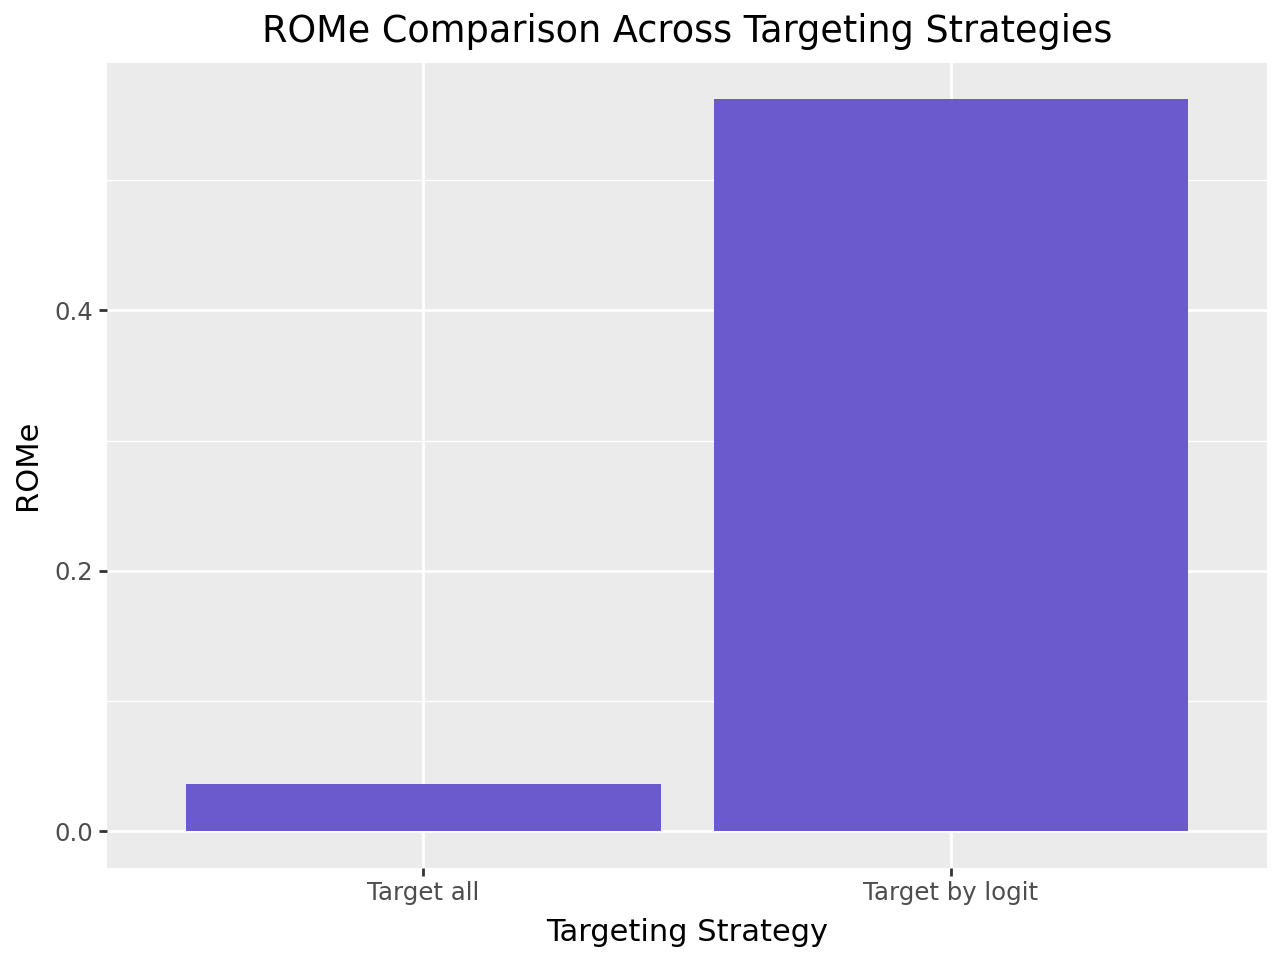

In [37]:
(
    ggplot(rome_df, aes(x="strategy", y="rome"))
    + geom_col(fill="slateblue")
    + labs(title = "ROMe Comparison Across Targeting Strategies",
           x="Targeting Strategy",
           y="ROMe"
           )
)

### Explanation

The comparison of Question 12 and 13 shows that the baseline approach delivers only modest profit and very low marketing efficiency, while the logit-based selective targeting strategy, which targets rollout customers with predicted purchase probabilities above the breakeven rate, substantially improves performance. The profit and ROMe bar charts confirm this improvement from both a scale and an efficiency perspective. So, the consistent advantage of selective targeting across these two metrics indicates that the model adds genuine decision value by focusing marketing resources on customers who are more likely to generate returns, rather than relying on blanket outreach.

You also have access to a dataset with the results from the deal offer roll-out (tuango_post.parquet). Tuango decided to contact all remaining 397,252 customers because this would provide data that could be used to evaluate different targeting approaches. The data has a "test" variable (test = 1 for the data used in the test, test = 0 for the remaining customers). Use this variable to evaluate the actual performance on the 'roll out' sample for the targeting approaches. Also re-create the plots from question 14 and 15 based on this new dataset.

In [38]:
tuango_post = pl.read_parquet("data/tuango_post.parquet")

In [39]:
pred_post = clf.predict(tuango_post).select(pl.col("prediction").alias("pred_logit"))

tuango_post = (
    tuango_post.with_columns(pred_post["pred_logit"])
    .with_columns((pl.col("pred_logit") > q11).alias("message_logit"))
    .with_columns(pl.lit(True).alias("message_all"))
)

In [ ]:
rollout = tuango_post.filter(pl.col("test") == 0)


nr_message_all_post = rollout.height
message_cost_all_post = nr_message_all_post * 9.0

nr_responses_all_post = rollout.filter(pl.col("buyer") == "yes").height
response_rate_all_post = nr_responses_all_post / nr_message_all_post

avg_ordersize_all_post = (
    rollout
    .filter(pl.col("buyer") == "yes")
    .select(pl.col("ordersize").mean())
    .item()
)

revenue_all_post = nr_responses_all_post * 49.0 * avg_ordersize_all_post
profit_all_post = 0.5 * revenue_all_post - message_cost_all_post
rome_all_post = profit_all_post / message_cost_all_post

In [ ]:
rollout_logit = rollout.filter(pl.col("message_logit"))

nr_message_logit_post = rollout_logit.height
message_cost_logit_post = nr_message_logit_post * 9.0

nr_responses_logit_post = rollout_logit.filter(pl.col("buyer") == "yes").height
response_rate_logit_post = nr_responses_logit_post / nr_message_logit_post

avg_ordersize_logit_post = (
    rollout_logit
    .filter(pl.col("buyer") == "yes")
    .select(pl.col("ordersize").mean())
    .item()
)

revenue_logit_post = nr_responses_logit_post * 49.0 * avg_ordersize_logit_post
profit_logit_post = 0.5 * revenue_logit_post - message_cost_logit_post
rome_logit_post = profit_logit_post / message_cost_logit_post

profit_all_post, profit_logit_post, rome_all_post, rome_logit_post

(111712.5, 887423.0, 0.031245909397561247, 0.5662712952434189)

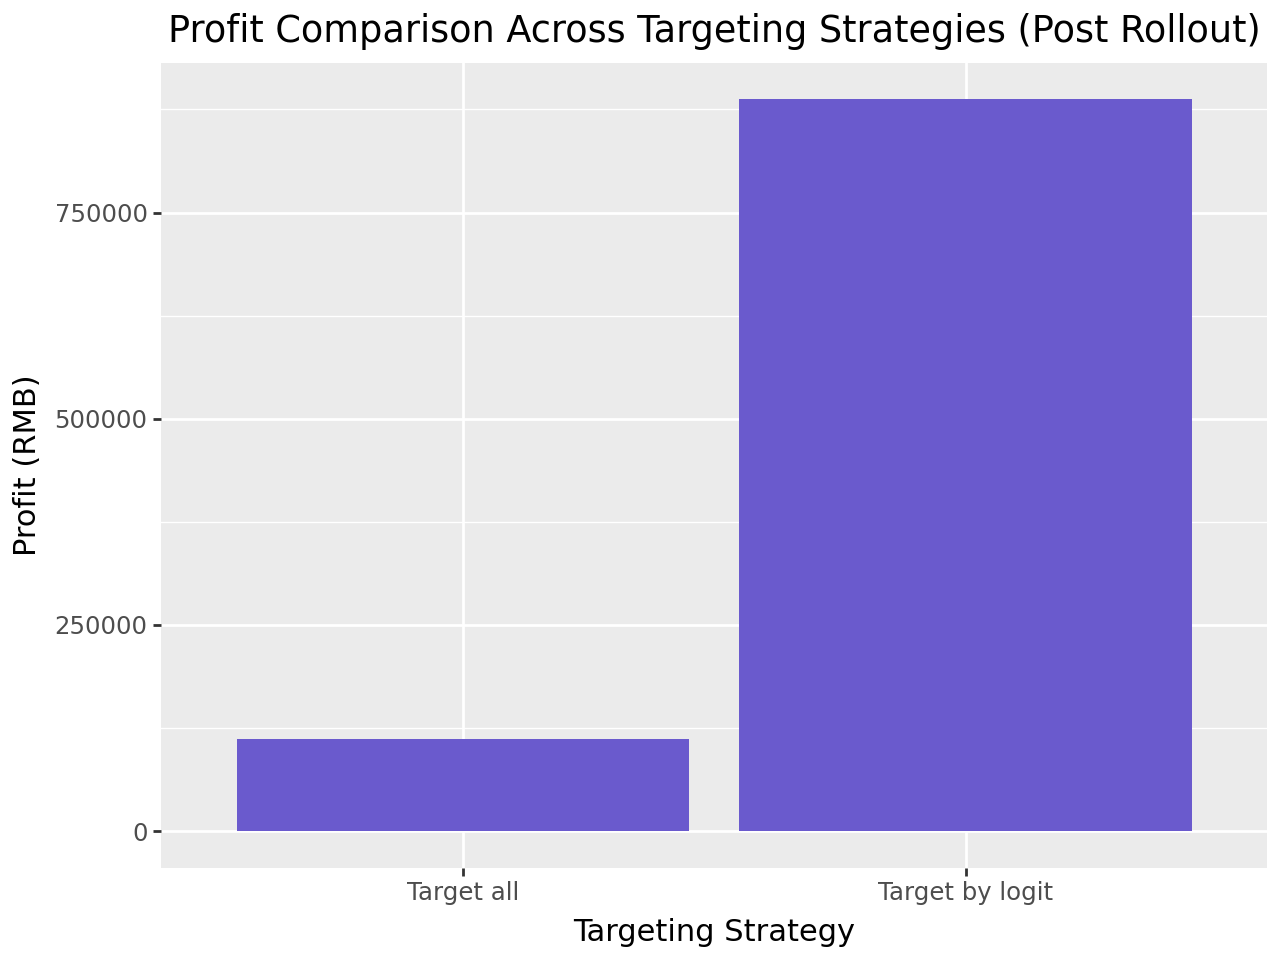

In [42]:
# post profit
profit_post_df = pl.DataFrame({
    "strategy": ["Target all", "Target by logit"],
    "profit": [profit_all_post, profit_logit_post],
})

(
    ggplot(profit_post_df, aes(x="strategy", y="profit"))
    + geom_col(fill="slateblue")
    + labs(
        title="Profit Comparison Across Targeting Strategies (Post Rollout)",
        x="Targeting Strategy",
        y="Profit (RMB)",
    )
)

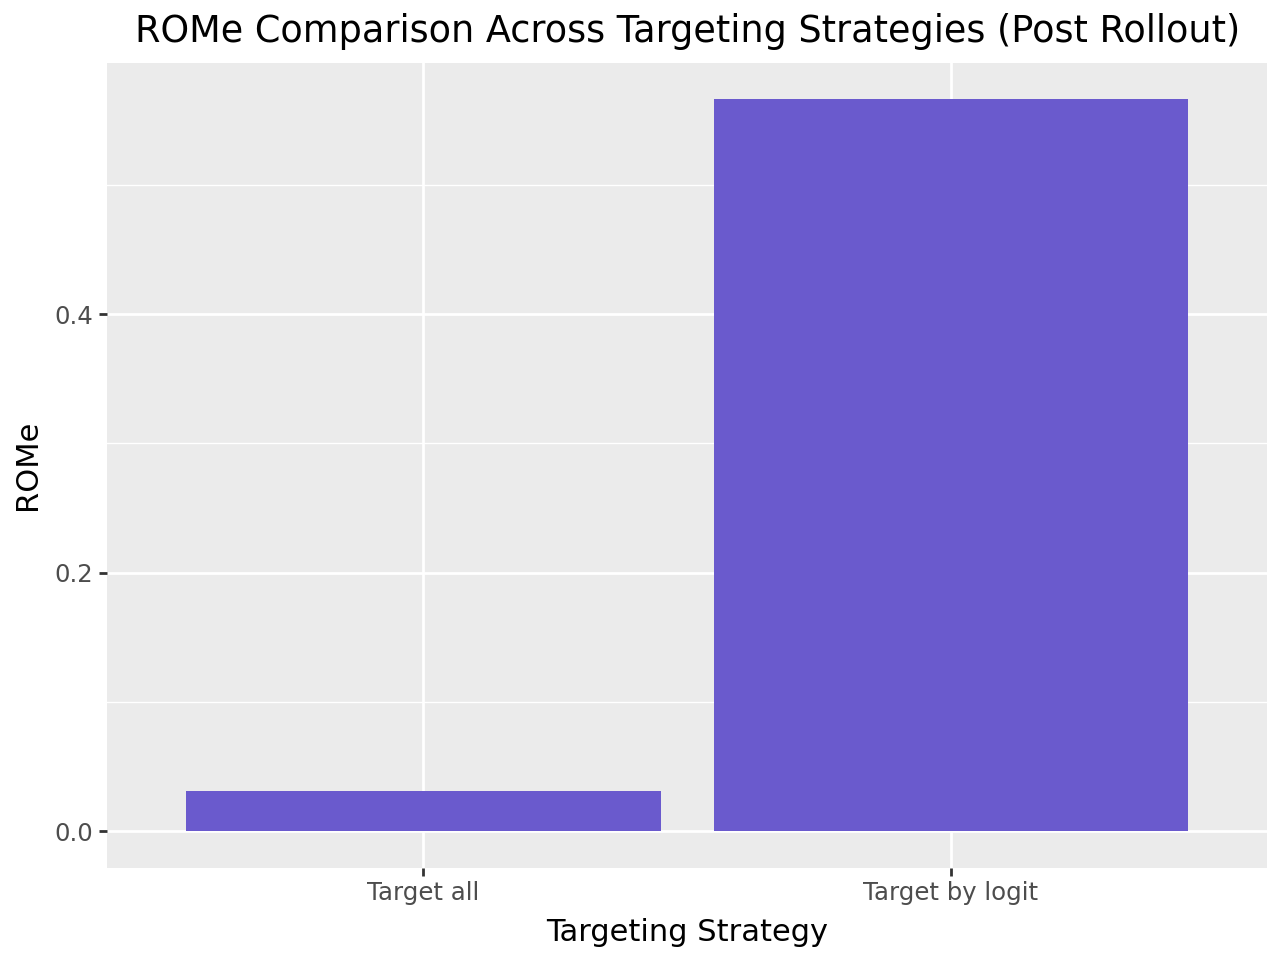

In [43]:
# post ROMe
rome_post_df = pl.DataFrame({
    "strategy": ["Target all", "Target by logit"],
    "rome": [rome_all_post, rome_logit_post],
})

(
    ggplot(rome_post_df, aes(x="strategy", y="rome"))
    + geom_col(fill="slateblue")
    + labs(
        title="ROMe Comparison Across Targeting Strategies (Post Rollout)",
        x="Targeting Strategy",
        y="ROMe",
    )
)

### Explanation

Using the post-rollout dataset, I evaluate realized performance on the rollout group for two strategies, targeting all customers versus targeting only customers flagged by the logit rule. The results show that logit-based targeting substantially outperforms targeting all in both total profit and marketing efficiency. Profit increases from about 111,713 RMB to about 887,423 RMB and ROMe rises from about 3.12% to about 56.63%. The post-rollout profit and ROMe bar charts visually confirm the same advantage. Overall, the realized rollout outcomes indicate that the model-based targeting rule successfully concentrates messages on higher-return customers and does not exhibit obvious overfitting.